# Can Value-at-Risk Predict Market Losses? A Backtest of a Brazilian Equity Portfolio

### Historical, Parametric and Gaussian Monte Carlo VaR, with diversification, tail-risk measures and out-of-sample validation

**Andre Luiz Cardoso** - andre.lc93@hotmail.com - [LinkedIn](https://linkedin.com/in/andre-l-cardoso) - [GitHub](https://github.com/AndreLuiz-Cardoso)

---

**Business question:** Can Value at Risk (VaR) be used as a statistical model to estimate - and predict out-of-sample - the losses of a real Brazilian equity portfolio (B3)?

A **1-day VaR of R$ 25,000 at 95%** means that, under the model's assumptions, losses **exceeding** R$ 25,000 are expected on about **5% of trading days**. VaR is a *quantile* of the loss distribution - **not** a forecast of the maximum possible loss. It was proposed by JP Morgan (1994) and remains a market standard, though Nassim Taleb ("The Black Swan") famously criticises its blindness to tail events. This notebook tests it with data.

**Methodological choice - historical tickers.** This is a *historical* study over the COVID-19 window (2019-2021). I therefore use the ticker that represented each company **during** the study period, rather than forcing today's symbols onto historical data (e.g. Arezzo `ARZZ3`, not the post-2024 merger ticker `AZZA3`). Corporate actions and ticker changes are discussed explicitly in Section 1.

**Roadmap:** 1) Data & corporate actions - 2) Exploratory analysis - 3) Pre/Post-COVID regime analysis - 4) Portfolio & diversification - 5) VaR (Historical, Parametric, Gaussian Monte Carlo) - 6) Expected Shortfall & Maximum Drawdown - 7) Rolling VaR - 8) Out-of-sample backtesting (Kupiec & Christoffersen) - 9) Conclusion.

> All VaR/ES figures are **1-day** at 95% unless stated. Educational project - not investment advice.

## 0. Setup

Reusable functions live at the top so the analysis cells stay readable. In a repo these would sit in a `src/` module imported here; kept inline for a single-file, reproducible notebook.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

plt.rcParams['figure.figsize'] = (11, 5)
ALPHA = 0.05          # 95% confidence
BALANCE = 1_000_000   # R$ invested


# ---------- data helpers ----------
def get_close(raw):
    """Return a clean 'Close' frame from yfinance, handling the MultiIndex
    returned when several tickers are downloaded at once."""
    if isinstance(raw.columns, pd.MultiIndex):
        lvl0 = raw.columns.get_level_values(0)
        key = 'Close' if 'Close' in lvl0 else 'Adj Close'
        return raw[key].copy()
    return raw.copy()


def download_prices(tickers, start, end):
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True)
    px = get_close(raw)
    empty = px.columns[px.isna().all()].tolist() if px.ndim == 2 else []
    if empty:
        print("WARNING - no data (dropped):", empty)
    px = (px.drop(columns=empty) if empty else px).dropna(how='all').ffill().dropna()
    return px, empty


# ---------- risk helpers ----------
def historical_var(returns, alpha=ALPHA):
    return np.percentile(returns.dropna(), alpha*100)

def parametric_var(returns, alpha=ALPHA):
    return returns.mean() + stats.norm.ppf(alpha) * returns.std()

def montecarlo_var(returns, alpha=ALPHA, n=100_000, seed=42):
    rng = np.random.default_rng(seed)
    sims = rng.normal(returns.mean(), returns.std(), n)   # Gaussian MC
    return np.percentile(sims, alpha*100)

def expected_shortfall(returns, alpha=ALPHA):
    """Mean loss GIVEN the loss is worse than the VaR (the average of the tail)."""
    v = historical_var(returns, alpha)
    tail = returns[returns <= v]
    return tail.mean()

def max_drawdown(returns):
    """Largest peak-to-trough drop of the cumulative return path."""
    cum = (1 + returns).cumprod()
    peak = cum.cummax()
    return (cum/peak - 1).min()


# ---------- backtesting: Kupiec & Christoffersen ----------
def kupiec_pof(returns, var_level, alpha=ALPHA):
    """Kupiec Proportion-of-Failures test (unconditional coverage)."""
    x = (returns < var_level).astype(int)
    n, f = len(x), x.sum()
    pi = f/n if n else np.nan
    if f == 0 or f == n:
        return dict(exceptions=int(f), n=int(n), rate=pi, LR=np.nan, p_value=np.nan)
    LR = -2*((n-f)*np.log(1-alpha) + f*np.log(alpha)
             - (n-f)*np.log(1-pi) - f*np.log(pi))
    p = 1 - stats.chi2.cdf(LR, df=1)
    return dict(exceptions=int(f), n=int(n), rate=pi, LR=LR, p_value=p)

def christoffersen_ind(returns, var_level):
    """Christoffersen test of independence of exceptions (clustering)."""
    x = (returns < var_level).astype(int).values
    T = np.zeros((2, 2))
    for i in range(1, len(x)):
        T[x[i-1], x[i]] += 1
    n00, n01, n10, n11 = T[0,0], T[0,1], T[1,0], T[1,1]
    if (n00+n01) == 0 or (n10+n11) == 0 or (n01+n11) == 0:
        return dict(LR=np.nan, p_value=np.nan)
    p01 = n01/(n00+n01); p11 = n11/(n10+n11); p = (n01+n11)/(n00+n01+n10+n11)
    def _l(pr, k0, k1):
        pr = min(max(pr, 1e-12), 1-1e-12)
        return k0*np.log(1-pr) + k1*np.log(pr)
    LR = -2*((_l(p, n00, n01) + _l(p, n10, n11)) - (_l(p01, n00, n01) + _l(p11, n10, n11)))
    return dict(LR=LR, p_value=1 - stats.chi2.cdf(LR, df=1))

print("Helpers loaded.")

Helpers loaded.


## 1. Data and corporate actions

**Portfolio (10 B3 stocks, historical tickers for the 2019-2021 window):**

Because this is a historical study, I use the symbol each company traded under *at the time*. Several of these later changed due to mergers or delistings - documented below so the reader understands the survivorship and corporate-action context.

In [24]:
# ticker -> weight (%)   -- HISTORICAL tickers for the COVID window
portfolio = {
    'ARZZ3.SA': 10,   # Arezzo (retail)      -> later AZZA3 (merged with Soma, Aug/2024)
    'B3SA3.SA': 10,   # B3 (exchange)
    'KLBN11.SA': 10,  # Klabin (pulp & paper)
    'RENT3.SA': 10,   # Localiza (car rental)
    'LAME4.SA': 5,    # Lojas Americanas     -> became AMER3; judicial recovery after 2023 fraud
    'MULT3.SA': 10,   # Multiplan (malls)
    'PETR4.SA': 10,   # Petrobras (oil & gas)
    'CRFB3.SA': 10,   # Carrefour Brasil / Atacadao (retail)
    'SULA11.SA': 10,  # SulAmerica (insurance) -> delisted, absorbed by Rede D'Or (Dec/2022)
    'VALE3.SA': 15,   # Vale (mining)
}

START, END = '2019-08-30', '2021-08-27'
prices, dropped = download_prices(list(portfolio.keys()), START, END)

surv = [t for t in portfolio if t in prices.columns]
missing = [t for t in portfolio if t not in prices.columns]
if missing:
    print("Tickers with NO data in this window:", missing,
          "\n-> If any historical ticker fails, check the exact symbol on Yahoo Finance.")

weights = np.array([portfolio[t] for t in surv], dtype=float)
weights_raw = weights.copy()
weights = weights / weights.sum()   # renormalise over available assets
prices = prices[surv]

print(f"\nAssets requested: {len(portfolio)} | assets used: {len(surv)}")
if len(surv) != len(portfolio):
    print("NOTE: fewer than 10 assets -> the portfolio was renormalised. "
          "Investigate the missing ticker before publishing.")
prices.tail()

$ARZZ3.SA: possibly delisted; no timezone found
[*******************   40%                       ]  4 of 10 completed$SULA11.SA: possibly delisted; no timezone found
[**********************50%                       ]  5 of 10 completed$CRFB3.SA: possibly delisted; no timezone found
$LAME4.SA: possibly delisted; no timezone found  ]  8 of 10 completed
[*********************100%***********************]  10 of 10 completed

4 Failed downloads:
['ARZZ3.SA', 'SULA11.SA', 'CRFB3.SA', 'LAME4.SA']: possibly delisted; no timezone found


WARNING - no data (dropped): ['ARZZ3.SA', 'CRFB3.SA', 'LAME4.SA', 'SULA11.SA']
Tickers with NO data in this window: ['ARZZ3.SA', 'LAME4.SA', 'CRFB3.SA', 'SULA11.SA'] 
-> If any historical ticker fails, check the exact symbol on Yahoo Finance.

Assets requested: 10 | assets used: 6
NOTE: fewer than 10 assets -> the portfolio was renormalised. Investigate the missing ticker before publishing.


Ticker,B3SA3.SA,KLBN11.SA,RENT3.SA,MULT3.SA,PETR4.SA,VALE3.SA
Date,,,,,,
2021-08-20,11.832335,16.341534,49.456074,17.742970,8.113336,58.442631
2021-08-23,11.374042,16.713388,47.519260,17.383205,8.241444,57.633846
2021-08-24,11.582355,17.045397,48.041359,17.931028,8.412251,59.736694
2021-08-25,11.657352,17.709419,48.445553,17.824736,8.458002,59.610889
2021-08-26,11.382373,17.510214,47.123478,17.227846,8.384799,58.850025


> **Reproducibility note.** If a historical ticker (e.g. `SULA11.SA`, `LAME4.SA`) is no longer served by Yahoo Finance, it will appear in the "NO data" list above. Two honest options: (a) source that series from another provider, or (b) state that the asset is excluded and the weights renormalised. Do **not** silently swap in a different company for the historical case - that changes the economic question being asked.

## 2. Exploratory analysis

### 2.1 Prices before vs. after the pandemic (rebased to 100)

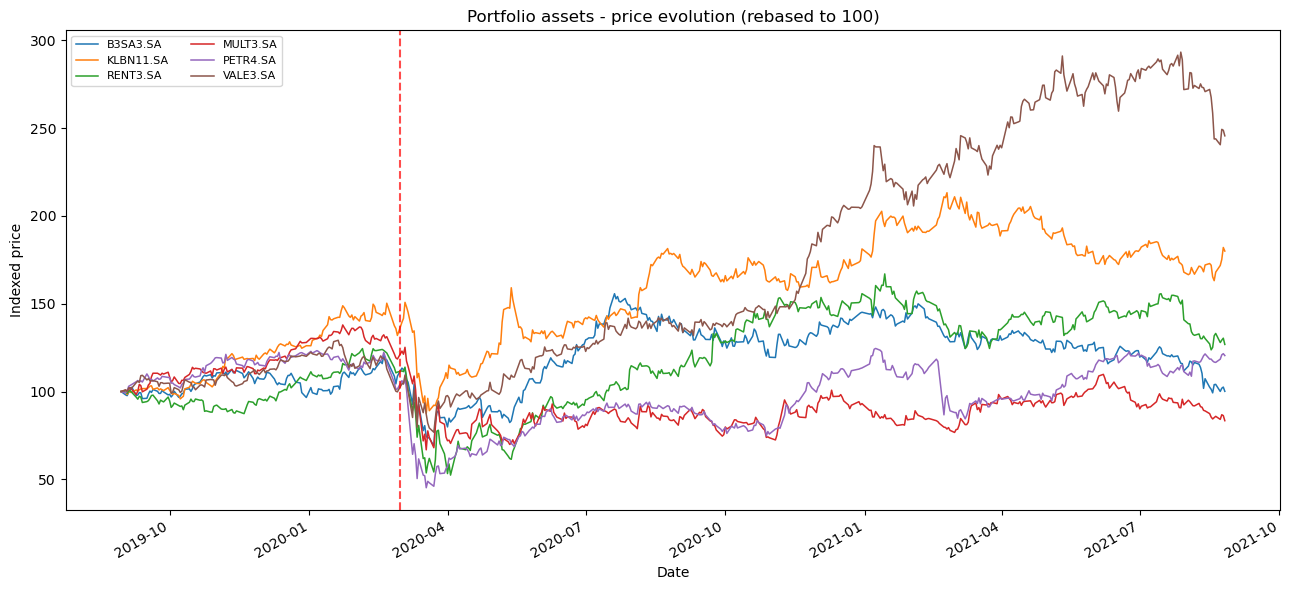

In [25]:
normed = prices / prices.iloc[0] * 100
ax = normed.plot(figsize=(13, 6), linewidth=1.1)
ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.7)
ax.set_title('Portfolio assets - price evolution (rebased to 100)')
ax.set_ylabel('Indexed price'); ax.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

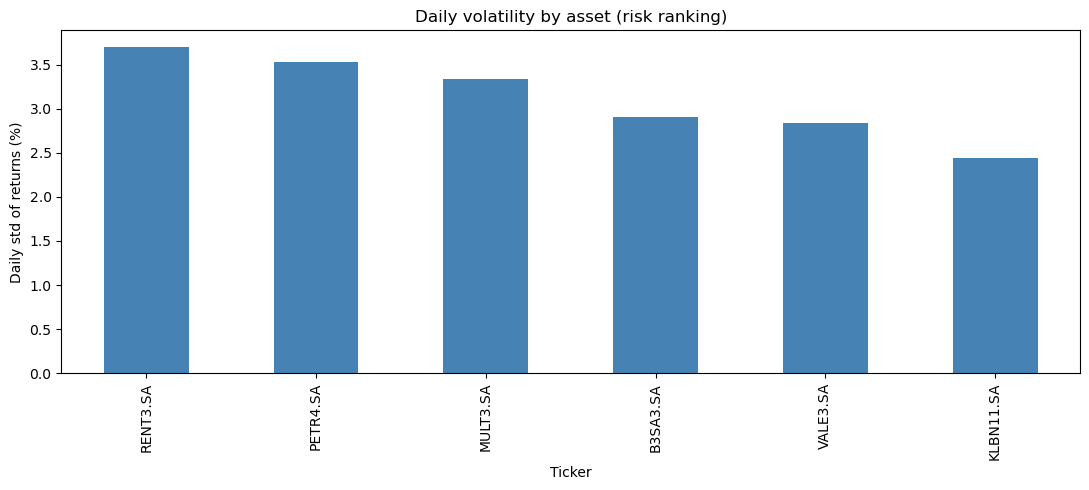

Ticker
RENT3.SA     3.703
PETR4.SA     3.535
MULT3.SA     3.339
B3SA3.SA     2.908
VALE3.SA     2.841
KLBN11.SA    2.438
dtype: float64

In [26]:
returns = prices.pct_change().dropna()

vol = returns.std().sort_values(ascending=False) * 100
ax = vol.plot(kind='bar', color='steelblue')
ax.set_title('Daily volatility by asset (risk ranking)')
ax.set_ylabel('Daily std of returns (%)')
plt.tight_layout(); plt.show()
vol.round(3)

## 3. Pre/Post-COVID regime analysis

The case asks explicitly whether risk changed with the pandemic. I split on **1 March 2020** and compare volatility and correlation across the two regimes.

In [27]:
split = pd.Timestamp('2020-03-01')
pre  = returns[returns.index <  split]
post = returns[returns.index >= split]

vol_table = pd.DataFrame({
    'Vol pre-COVID (%)':  pre.std()*100,
    'Vol post-COVID (%)': post.std()*100,
})
vol_table['Change (pp)'] = (vol_table['Vol post-COVID (%)'] - vol_table['Vol pre-COVID (%)']).round(3)
vol_table.round(3)

,Vol pre-COVID (%),Vol post-COVID (%),Change (pp)
Ticker,,,
B3SA3.SA,2.151,3.120,0.970
KLBN11.SA,1.808,2.614,0.806
RENT3.SA,1.933,4.126,2.193
MULT3.SA,1.704,3.725,2.021
PETR4.SA,1.809,3.943,2.134
VALE3.SA,2.053,3.056,1.003


In [28]:
def corr_summary(r):
    c = r.corr().values
    iu = np.triu_indices_from(c, k=1)     # upper triangle, exclude diagonal
    vals = c[iu]
    return pd.Series({'avg_pairwise': vals.mean(), 'max': vals.max(), 'min': vals.min()})

corr_regime = pd.DataFrame({
    'Pre-COVID':  corr_summary(pre),
    'Post-COVID': corr_summary(post),
}).round(3)
print(corr_regime)
print("\nInterpretation to check against YOUR output: if average pairwise correlation")
print("RISES from pre to post, diversification weakens exactly when it's needed most.")

              Pre-COVID  Post-COVID
avg_pairwise      0.420       0.475
max               0.646       0.657
min               0.284       0.232

Interpretation to check against YOUR output: if average pairwise correlation
RISES from pre to post, diversification weakens exactly when it's needed most.


**Insight (verify against the numbers above):** volatility typically rises after March 2020, and if average pairwise correlation also rises, it illustrates a key market-risk lesson - *diversification benefits can weaken precisely during stress, because correlations tend to increase when markets fall together.*

## 4. Portfolio construction and the diversification effect

In [29]:
portfolio_return = returns[surv].dot(weights)
portfolio_return.name = 'Portfolio'

indiv_vol = returns[surv].std()
weighted_avg_vol = (indiv_vol * weights).sum() * 100
portfolio_vol = portfolio_return.std() * 100
print(f"Weighted average of individual volatilities: {weighted_avg_vol:.3f}%")
print(f"Actual portfolio volatility:                 {portfolio_vol:.3f}%")
print(f"Risk reduced by diversification:             {weighted_avg_vol - portfolio_vol:.3f} pp")

Weighted average of individual volatilities: 3.105%
Actual portfolio volatility:                 2.348%
Risk reduced by diversification:             0.757 pp


**Insight:** portfolio volatility is lower than the weighted average of individual volatilities - the diversification benefit, quantified.

## 5. VaR - three methods

Normality check first (parametric and Gaussian Monte Carlo assume Normal returns).

Shapiro-Wilk p-value: 0.000000  ->  Normal? False


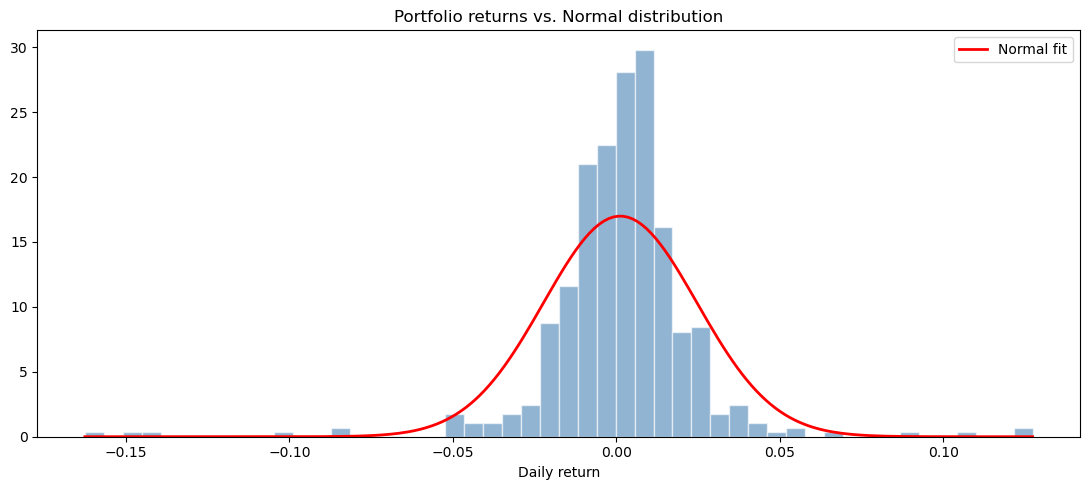

In [30]:
stat, p = stats.shapiro(portfolio_return)
print(f"Shapiro-Wilk p-value: {p:.6f}  ->  Normal? {p > 0.05}")

x = np.linspace(portfolio_return.min(), portfolio_return.max(), 200)
plt.hist(portfolio_return, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='white')
plt.plot(x, stats.norm.pdf(x, portfolio_return.mean(), portfolio_return.std()), 'r-', lw=2, label='Normal fit')
plt.title('Portfolio returns vs. Normal distribution'); plt.xlabel('Daily return'); plt.legend()
plt.tight_layout(); plt.show()

In [31]:
var_hist  = historical_var(portfolio_return)
var_param = parametric_var(portfolio_return)
var_mc    = montecarlo_var(portfolio_return)

for name, v in [('Historical', var_hist), ('Parametric', var_param), ('Gaussian Monte Carlo', var_mc)]:
    print(f"{name:22s} VaR 95%: {v:.2%}  -> R$ {v*BALANCE:,.0f}")

Historical             VaR 95%: -2.65%  -> R$ -26,508
Parametric             VaR 95%: -3.74%  -> R$ -37,445
Gaussian Monte Carlo   VaR 95%: -3.78%  -> R$ -37,762


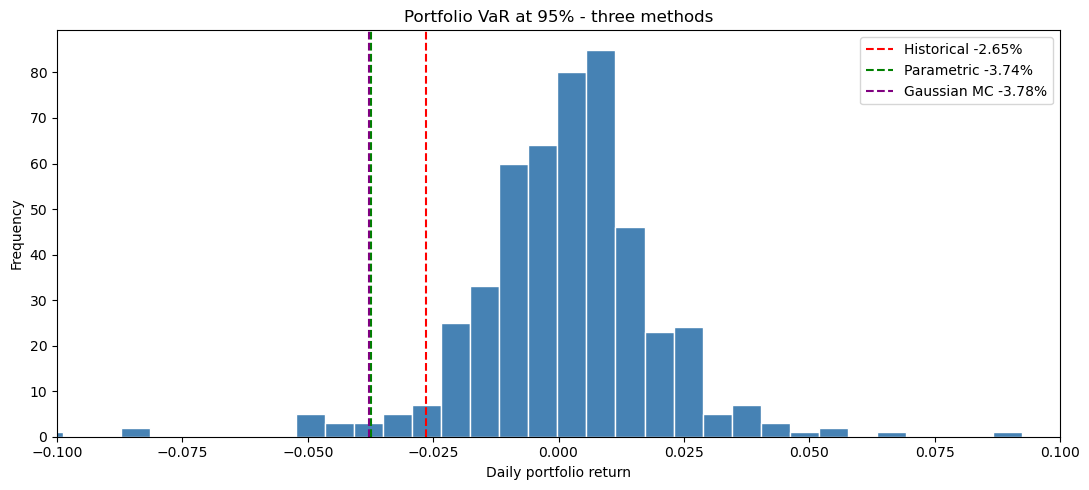

In [32]:
plt.hist(portfolio_return, bins=50, color='steelblue', edgecolor='white')
plt.axvline(var_hist,  color='red',    linestyle='--', label=f'Historical {var_hist:.2%}')
plt.axvline(var_param, color='green',  linestyle='--', label=f'Parametric {var_param:.2%}')
plt.axvline(var_mc,    color='purple', linestyle='--', label=f'Gaussian MC {var_mc:.2%}')
plt.xlim(-0.1, 0.1); plt.legend()
plt.title('Portfolio VaR at 95% - three methods')
plt.xlabel('Daily portfolio return'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

**Reading it:** parametric and Gaussian Monte Carlo are close (both assume Normality); historical can differ because it uses the real, fat-tailed distribution. My Monte Carlo is deliberately the *Gaussian* version - it shares the parametric blind spot. A more faithful variant would bootstrap the empirical returns.

## 6. Expected Shortfall and Maximum Drawdown

VaR tells us **where** the worst 5% begins. Two complementary measures make the tail picture complete.

In [33]:
es_hist = expected_shortfall(portfolio_return)
mdd = max_drawdown(portfolio_return)

print(f"Historical VaR 95%:        {var_hist:.2%}  -> R$ {var_hist*BALANCE:,.0f}")
print(f"Expected Shortfall 95%:    {es_hist:.2%}  -> R$ {es_hist*BALANCE:,.0f}")
print(f"Portfolio volatility:      {portfolio_vol:.2f}%")
print(f"Maximum drawdown (period): {mdd:.2%}")

Historical VaR 95%:        -2.65%  -> R$ -26,508
Expected Shortfall 95%:    -5.87%  -> R$ -58,669
Portfolio volatility:      2.35%
Maximum drawdown (period): -46.12%


**Insight:** *VaR tells us where the tail begins; Expected Shortfall tells us how severe it is once we are in it* (the average loss beyond VaR). Maximum drawdown adds the realised cumulative loss - the worst peak-to-trough the portfolio actually suffered over the window.

## 7. Rolling VaR (dynamic, 250-day window)

Instead of a single static VaR, compute a **250-day rolling historical VaR** and overlay realised returns. This shows the model adapting as volatility rises.

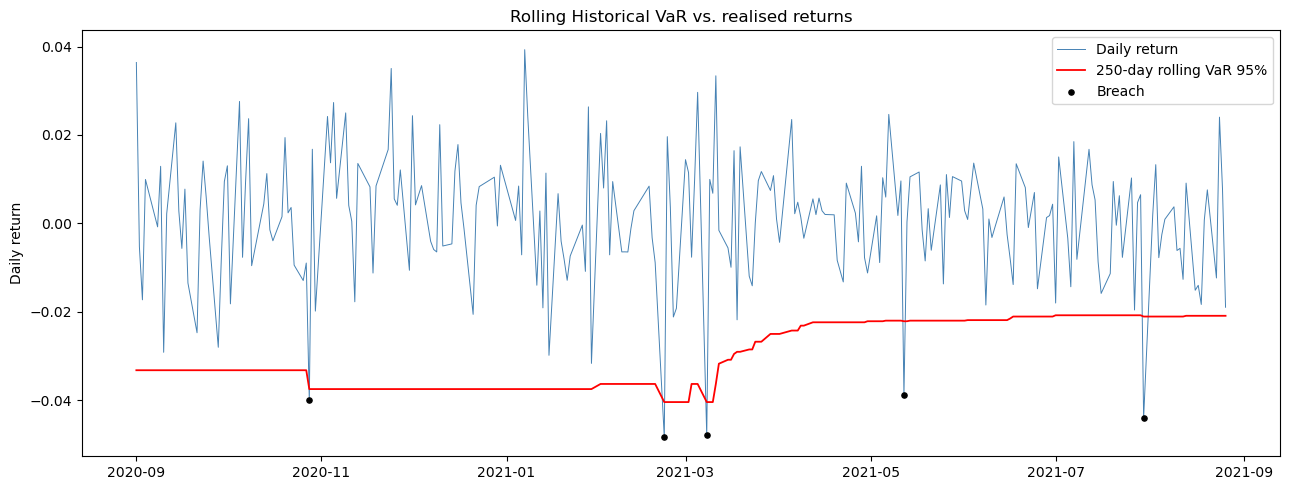

Rolling-VaR breaches: 5/243 = 2.1% (expected ~5%)


In [34]:
WIN = 250
rolling_var = portfolio_return.rolling(WIN).apply(lambda w: np.percentile(w, ALPHA*100), raw=True)
rv = rolling_var.dropna()
aligned = portfolio_return.loc[rv.index]
breaches_roll = aligned[aligned < rv]

plt.figure(figsize=(13, 5))
plt.plot(aligned.index, aligned.values, color='steelblue', lw=0.7, label='Daily return')
plt.plot(rv.index, rv.values, color='red', lw=1.3, label=f'{WIN}-day rolling VaR 95%')
plt.scatter(breaches_roll.index, breaches_roll.values, color='black', s=14, zorder=5, label='Breach')
plt.title('Rolling Historical VaR vs. realised returns')
plt.ylabel('Daily return'); plt.legend(); plt.tight_layout(); plt.show()

print(f"Rolling-VaR breaches: {len(breaches_roll)}/{len(aligned)} = {len(breaches_roll)/len(aligned):.1%} (expected ~5%)")

## 8. Out-of-sample backtesting with formal coverage tests

Estimate VaR on a **pre-COVID training window** (Aug-Nov 2019); test it on everything after. Then run **Kupiec** (is the exception *rate* correct?) and **Christoffersen** (are exceptions *independent*, or clustered?).

In [35]:
train = portfolio_return['2019-08-30':'2019-11-30']
test  = portfolio_return['2019-12-01':]
var_train = historical_var(train)

breaches = test[test < var_train]
print(f"VaR (train window): {var_train:.2%}  -> R$ {var_train*BALANCE:,.0f}")
print(f"Test days: {len(test)} | breaches: {len(breaches)} "
      f"({len(breaches)/len(test):.1%}) | expected ~5%\n")

kp = kupiec_pof(test, var_train)
ch = christoffersen_ind(test, var_train)
print("Kupiec POF (unconditional coverage): "
      f"LR={kp['LR']:.2f}  p-value={kp['p_value']:.4f}  "
      f"-> {'reject' if (kp['p_value'] is not None and kp['p_value']<0.05) else 'do not reject'} correct coverage")
print("Christoffersen (independence):        "
      f"LR={ch['LR']:.2f}  p-value={ch['p_value']:.4f}  "
      f"-> {'exceptions clustered' if (ch['p_value'] is not None and ch['p_value']<0.05) else 'no clustering detected'}")

VaR (train window): -1.53%  -> R$ -15,348
Test days: 429 | breaches: 56 (13.1%) | expected ~5%

Kupiec POF (unconditional coverage): LR=41.39  p-value=0.0000  -> reject correct coverage
Christoffersen (independence):        LR=0.56  p-value=0.4523  -> no clustering detected


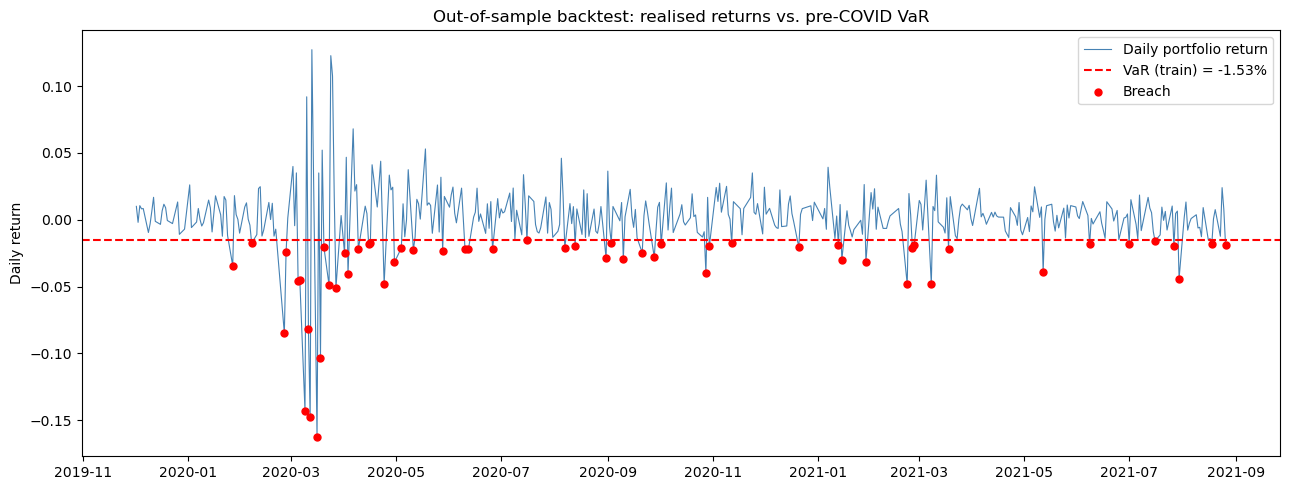

In [36]:
plt.figure(figsize=(13, 5))
plt.plot(test.index, test.values, color='steelblue', lw=0.8, label='Daily portfolio return')
plt.axhline(var_train, color='red', linestyle='--', label=f'VaR (train) = {var_train:.2%}')
plt.scatter(breaches.index, breaches.values, color='red', s=25, zorder=5, label='Breach')
plt.title('Out-of-sample backtest: realised returns vs. pre-COVID VaR')
plt.ylabel('Daily return'); plt.legend(); plt.tight_layout(); plt.show()

**Insight (verify against YOUR p-values):** a static VaR calibrated on a calm window is typically breached far above 5% once COVID hits. A significant Kupiec result says the exception *rate* is wrong; a significant Christoffersen result says exceptions *cluster* (they arrive together, in the crash) - both are exactly what Taleb's critique predicts. This is formal model-validation language, not just a raw breach count.

## 9. A real-world stress example beyond the sample

In January 2023, **Lojas Americanas** (in my portfolio as `LAME4`, later `AMER3`) fell roughly **-77% in a single day** after disclosing an accounting fraud. This event lies **outside** the 2019-2021 study window and is therefore **not part of the backtest** - I include it only to illustrate the kind of idiosyncratic shock that no historical VaR can anticipate. Presenting it as outside-sample is the honest framing.

## 10. Conclusion

**Can VaR predict future losses on a B3 portfolio?**

- **As a baseline, yes** - in normal regimes, historical VaR gives an interpretable estimate of expected worst-case daily loss; diversification measurably lowers portfolio risk; and Expected Shortfall / drawdown round out the tail picture.
- **On its own, for tail events, no** - the backtest (and its Kupiec/Christoffersen results) shows VaR calibrated pre-COVID is breached well above 5%, with clustered exceptions, once the regime shifts. Returns are not Normal (fat tails), so VaR must be complemented with ES, stress testing and scenario analysis.

**Skills demonstrated:** data ingestion & corporate-action handling - regime analysis - portfolio math & diversification - three VaR methods (historical, parametric, Gaussian Monte Carlo) - Expected Shortfall, drawdown, rolling VaR - **formal out-of-sample validation (Kupiec, Christoffersen)** - honest treatment of model limits.

*Tools: Python, pandas, NumPy, Matplotlib, SciPy, yfinance. 1-day VaR at 95%. Educational project - not investment advice.*